In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
from sklearn.ensemble import IsolationForest
from ucimlrepo import fetch_ucirepo
air_quality = fetch_ucirepo(id=360)


In [17]:
#convert to dataframe
df=air_quality.data.features
(df.head())

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [21]:
#parameters for isolation forest
df=df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]
n_estimators = 100
max_samples = 'auto'
contamination = 0.01
random_state = 42
model=IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=contamination, random_state=random_state)
model.fit(df)


,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [22]:
anomoly_labels=model.predict(df)
df['anomaly']=anomoly_labels
print(df['anomaly'].value_counts())

anomaly
 1    9263
-1      94
Name: count, dtype: int64


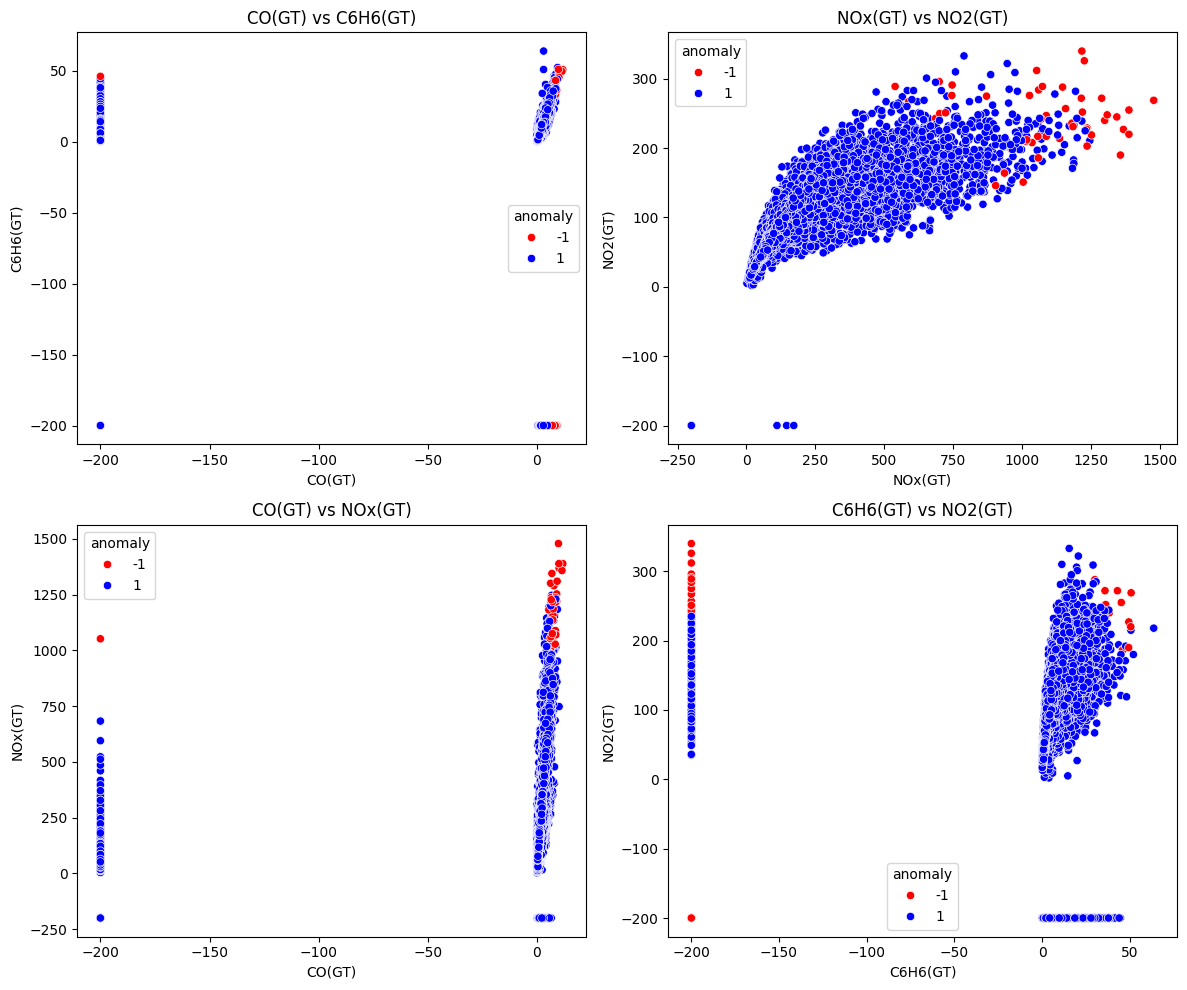

In [25]:
fig,axes=plt.subplots(2,2,figsize=(12,10))
sns.scatterplot(data=df, x='CO(GT)', y='C6H6(GT)', hue='anomaly', palette={1:'blue', -1:'red'}, ax=axes[0,0])
axes[0,0].set_title('CO(GT) vs C6H6(GT)')
sns.scatterplot(data=df, x='NOx(GT)', y='NO2(GT)', hue='anomaly', palette={1:'blue', -1:'red'}, ax=axes[0,1])
axes[0,1].set_title('NOx(GT) vs NO2(GT)')
sns.scatterplot(data=df, x='CO(GT)', y='NOx(GT)', hue='anomaly', palette={1:'blue', -1:'red'}, ax=axes[1,0])
axes[1,0].set_title('CO(GT) vs NOx(GT)')
sns.scatterplot(data=df, x='C6H6(GT)', y='NO2(GT)', hue='anomaly', palette={1:'blue', -1:'red'}, ax=axes[1,1])
axes[1,1].set_title('C6H6(GT) vs NO2(GT)')
plt.tight_layout()


In [30]:
import joblib
model_path="C:\\Users\\VISHNU\\Downloads\\MachineLearning\\MachineLearning\\feature_selection\\isolation_forest_model.pkl"
joblib.dump(model, model_path)

['C:\\Users\\VISHNU\\Downloads\\MachineLearning\\MachineLearning\\feature_selection\\isolation_forest_model.pkl']